# Predicting Next Lap Pit Stops in Formula 1 Using Machine Learning.

Pit stop strategy plays a crucial role in determining race outcomes in Formula 1. Teams must decide the optimal moment to bring a driver into the pits, balancing factors such as tire degradation, track position, race pace, and competitor behavior.

In this project, we aim to model and predict whether a driver will make a pit stop on the next lap using historical race data. This problem is framed as a binary classification task, where the target variable indicates whether a pit stop occurs (1) or not (0).

By analyzing patterns in race dynamics—such as lap number, tire age, and relative position—we seek to identify the key factors influencing pit decisions and evaluate how accurately these events can be predicted using machine learning models.

We begin by importing necessary libraries, loading the data and inspecting it's structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mikedammy/data-science-portfolio/refs/heads/main/f1-pit-stop-project/f1_strategy_dataset_v4.csv")

# Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [4]:
df[['LapTime (s)', 'LapTime_Delta']].describe()

,LapTime (s),LapTime_Delta
count,101371.000000,101371.000000
mean,92.587188,-0.203891
std,33.231414,45.344910
min,67.012000,-2403.895000
25%,82.021000,-7.253000
50%,91.167000,-0.027000
75%,99.356000,5.705000
max,2526.253000,2433.472000


This section explores the structure, distributions, and key characteristics of the dataset used to predict pit stop behavior in Formula 1.

The dataset contains 101,371 observations and 16 features, capturing lap-by-lap race dynamics across multiple seasons.

**Column Description**

1. **Driver**: A 3-letter abbreviation representing each driver. There are 31 unique drivers in the dataset.

2. **Lap Number**: Indicates the lap within a race, ranging from 1 to 78.

3. **Compound**: The tyre compound used (Soft, Medium, Hard, Intermediate, Wet).
    - Categorical feature
    - 66 missing values were removed
    - Will be one-hot encoded

4. **Stint:** Represents the current tyre stint number (i.e., how many sets of tyres the driver has used), ranging from 1 to 8.

5. **Tyre Life:** Number of laps completed on the current tyre set, ranging from 1 to 78.

6. **Position:** Driver's track position at the end of the lap (1–20).

7. **Laptime (s):** Time taken to complete the lap (in seconds).
    - Range: 67 to 2526.25
    - Mean: 92.6
    - Median: 91.17
    - Standard deviation: 33.23

8. **Race:** The specific Grand Prix event (28 unique races).

9. **Year:** The season in which the race occurred (2022–2025).

10. **Laptime Delta:** Relative difference in lap time compared to a reference.
    - Key indicator of pace variation
    - Mean: -0.2
    - Median: -0.027

11.  **Cumulative Degradation:** Estimated performance loss due to tyre wear over time. Captures long-term tyre effects.

12. **Pit Stop:** Binary indicator showing whether the driver pitted during the current lap.

13. **Race Progress:** Percentage of race completed (0 to 1).

14. **Normalized Tyre Life:** Tyre life scaled relative to expected lifespan for comparability across circuits.

15. **Position Change:** Change in position during the lap (positive = gained places, negative = lost places).

16. **Pit Next Lap (Target Variable):** Binary variable indicating whether the driver will pit on the next lap.
---

**Key Observations from EDA**

- Pit stop decisions are likely influenced by tyre degradation, race progress, and track position.

- Several variables show skewness and outliers, requiring careful preprocessing.

- Some engineered features (e.g., normalized tyre life) already improve cross-race comparability.

# Data Cleaning

In this section, I drop rows with nan values, and drop extreme outliers from the following columns:
- LapTime (s)
- LapTime_Delta
- Cummulative Degradation

As these columns are continuous in nature and can theoretically range from negative infinity to infinity.

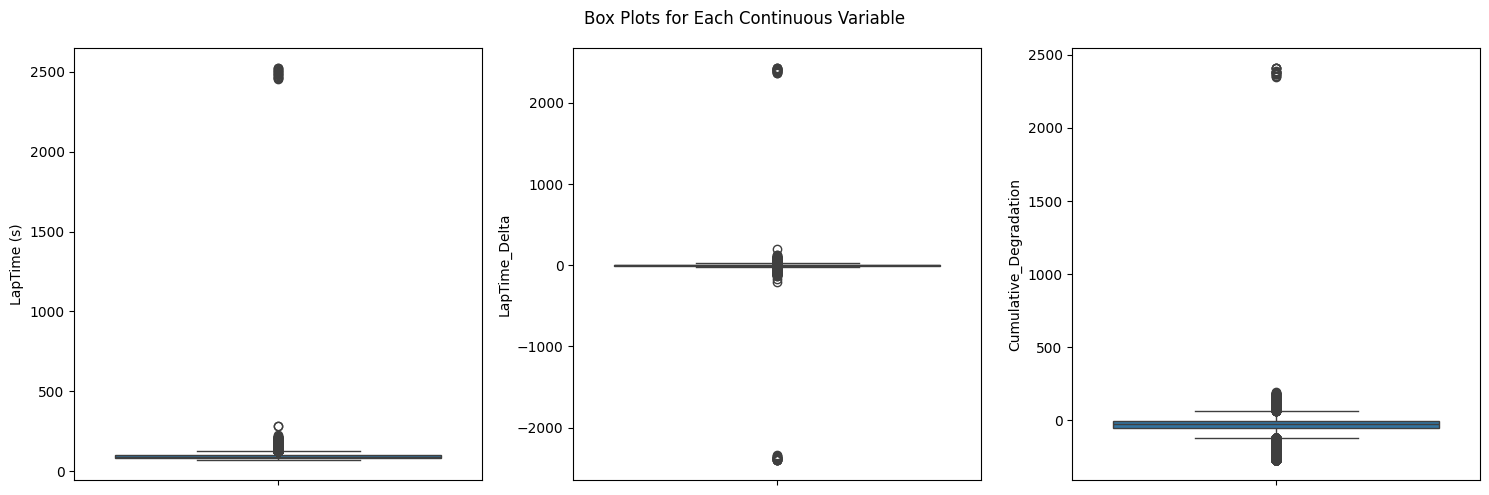

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

sns.boxplot(df['LapTime (s)'], ax=axes[0])
sns.boxplot(df['LapTime_Delta'], ax=axes[1])
sns.boxplot(df['Cumulative_Degradation'], ax=axes[2])

fig.suptitle("Box Plots for Each Continuous Variable")

plt.tight_layout()
plt.show()

According to the above boxplots, it is evident thay=t there are some extreme events which will distort the coefficients of the model, hence we'll drop those outliers.

In [6]:
# Dropping NaN rows
df = df.dropna().reset_index(drop=True)

#Dropping outliers
df = df[
    (df['LapTime (s)'] <= 2000) &
    (df['LapTime_Delta'] <= 2000) &
    (df['LapTime_Delta'] >= -2000) &
    (df['Cumulative_Degradation'] <= 2000)
].reset_index(drop=True)


In [7]:
df.shape

(101273, 16)

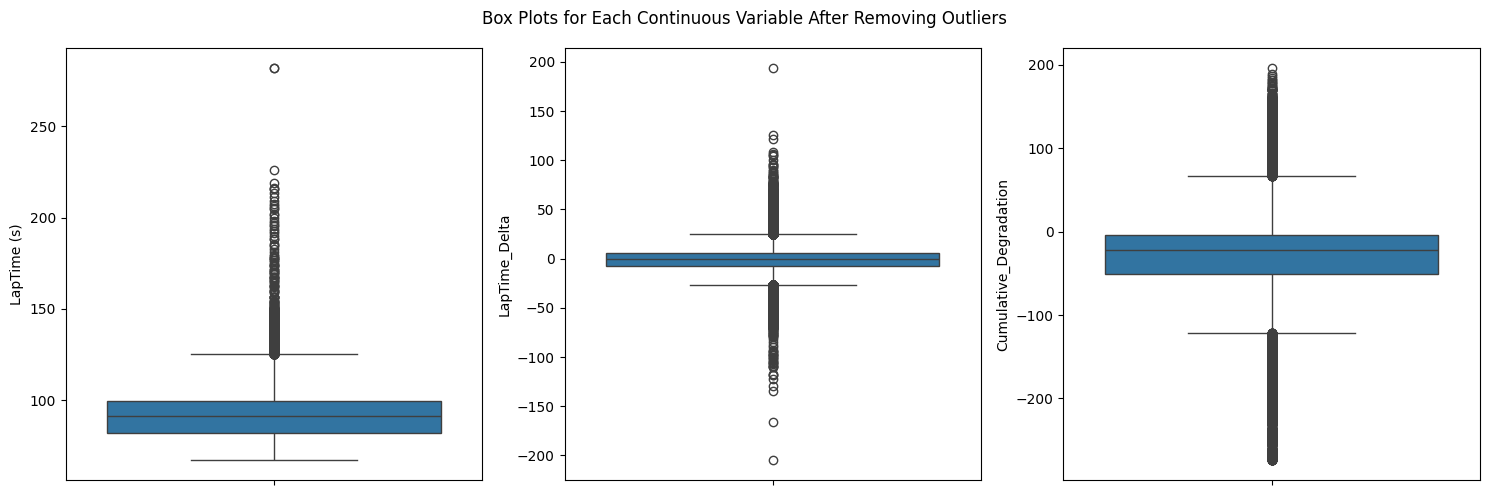

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

sns.boxplot(df['LapTime (s)'], ax=axes[0])
sns.boxplot(df['LapTime_Delta'], ax=axes[1])
sns.boxplot(df['Cumulative_Degradation'], ax=axes[2])

fig.suptitle("Box Plots for Each Continuous Variable After Removing Outliers")

plt.tight_layout()
plt.show()

# Preprocessing

**Declaring X and y Variables**

In this section I preprocess the data by first defining the predictors X and the target y.
___

**Stratified Shuffle Split**

Then split the variables into train and test using a stratified shuffle split to keep equal proportion of important variables, compound and PitNextLap.

___

**Scaling Using Robust Scaler**

In this step, I scale the numeric variables using Robust Scaler which is better than Standard Scaler due to its handling of outliers and high kurtosis.

The Robust Scaler uses the median and the IQR to scale variables.

$$x_{scaled} = \frac{x_i - \text{Q2}(x)}{\text{Q3}(x) - \text{Q1}(x)}$$

___

**One Hot Encoding**

Then I one hot encode the categorical columms. In this dataset, there's only one categorical column: Compound.

___

*The following columns will be left as is*:
- Pit Stop: This is a binary column,
- Race Progress: This has already been scaled, and
- Normalized Tyre Life: This has already been scaled.



In [9]:
# Declaring X and y

x_vars = ['LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'PitStop', 'RaceProgress', 'Normalized_TyreLife']
y_var = 'PitNextLap'

X = df[x_vars]
y = df[y_var]

In [10]:
# Stratified Shuffle Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1,
    stratify=df[['Compound', 'PitNextLap']],
    random_state=42
)

In [11]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Defining the columns to scale, categorise and leave as is

scale_cols = ['LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change']
cat_cols = ['Compound']
leave_cols = ['RaceProgress', 'Normalized_TyreLife', 'PitStop']

# Scaling the numeric variables and on hot encoding categorical variables using Column transformer

col_transform = ColumnTransformer(
    transformers=[
        ('scale', RobustScaler(), scale_cols),
        ('onehot', OneHotEncoder(drop='first'), cat_cols),
        ('leave', 'passthrough', leave_cols)
    ],
    remainder='passthrough'
)

# Model Selection

In this section, I use 3 models with no hyperparameter tuning and select the best performing one among them.

The models I use are:
- Logistic Regression, for it's simplicity and high interpretability,
- Random Forest Classifier, for it's ability to capture non-linear relationships, and
- Histogram Gradient Boosting Classifier

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [13]:
# Logistic Regression Model

log_reg = Pipeline(
    steps=[
        ('col_transform', col_transform),
        ('log_reg', LogisticRegression(random_state=42))
    ]
)

log_reg.fit(X_train, y_train)

Pipeline(steps=[('col_transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', RobustScaler(),
                                                  ['LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime (s)',
                                                   'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'Position_Change']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Compound']),
                                                 ('leave', 'passthrough',
                                                  ['RaceProgress',
                                                   'Normalized_TyreLife',
                                                   'PitStop'])])),
                ('log_reg', LogisticRegression(random_state=42))])

In [14]:
# Random Forest Model

forest = Pipeline(
    steps=[
        ('col_transform', col_transform),
        ('forest', RandomForestClassifier(random_state=42))
    ]
)

forest.fit(X_train, y_train)

Pipeline(steps=[('col_transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', RobustScaler(),
                                                  ['LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime (s)',
                                                   'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'Position_Change']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Compound']),
                                                 ('leave', 'passthrough',
                                                  ['RaceProgress',
                                                   'Normalized_TyreLife',
                                                   'PitStop'])])),
                ('forest', RandomForestClassifier(random_state=42))])

In [15]:
# Histogram Gradient Boosting Classifier Model

hist_grad = Pipeline(
    steps=[
        ('col_transform', col_transform),
        ('hist_grad', HistGradientBoostingClassifier(random_state=42))
    ]
)

hist_grad.fit(X_train, y_train)

Pipeline(steps=[('col_transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', RobustScaler(),
                                                  ['LapNumber', 'Stint',
                                                   'TyreLife', 'Position',
                                                   'LapTime (s)',
                                                   'LapTime_Delta',
                                                   'Cumulative_Degradation',
                                                   'Position_Change']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['Compound']),
                                                 ('leave', 'passthrough',
                                                  ['RaceProgress',
                                                   'Normalized_TyreLife',
                                                   'PitStop'])])),
                ('hist_grad', HistGradientBoostingClassifier(random_state=42))])

## Models Evaluation

In the next step I evaluate each model based on their training accuracy score and their test accuract score.

In [16]:
log_reg_train_score = log_reg.score(X_train, y_train)
log_reg_test_score = log_reg.score(X_test, y_test)

forest_train_score = forest.score(X_train, y_train)
forest_test_score = forest.score(X_test, y_test)

hist_grad_train_score = hist_grad.score(X_train, y_train)
hist_grad_test_score = hist_grad.score(X_test, y_test)

In [17]:
print(f'''
Logistic Regression Training Accuracy Score: {log_reg_train_score:.3f}
Logistic Regression Test Accuracy Score: {log_reg_test_score:.3f}

Random Forest Training Accuracy Score: {forest_train_score:.3f}
Random Forest Test Accuracy Score: {forest_test_score:.3f}

Histogram Gradient Boosting Classifier Training Accuracy Score: {hist_grad_train_score:.3f}
Histogram Gradient Boosting Classifier Test Accuracy Score: {hist_grad_test_score:.3f}
''')


Logistic Regression Training Accuracy Score: 0.771
Logistic Regression Test Accuracy Score: 0.771

Random Forest Training Accuracy Score: 1.000
Random Forest Test Accuracy Score: 0.945

Histogram Gradient Boosting Classifier Training Accuracy Score: 0.882
Histogram Gradient Boosting Classifier Test Accuracy Score: 0.871



## Choosing the Model to be Used

According to the above train and test results, the Random Forest Classifier has the best train and test accuracy. A 100% train accuracy suggests that the model has successfully memorized the data and the 5.5% drop in test performance suggests moderate overfitting.

On the other hand, the Histogram Gradient Boosting Classifier achieved lower training accuracy (88.2%) and test accuracy (87.1%), but with a much smaller generalization gap of 0.8%, indicating a more stable and consistent model.

This highlights a key trade-off between performance and generalization:

- Random Forest provides higher accuracy but is more prone to overfitting, while
- Histogram Gradient Boosting offers better generalization but lower predictive performance

Given the objective of maximizing predictive accuracy, the Random Forest model is selected as the preferred model, while acknowledging its tendency to overfit.

___

Future improvements could focus on reducing overfitting in the Random Forest model through hyperparameter tuning, while also optimizing the Gradient Boosting model to close the performance gap.

# Further Model Evaluation

In this section I further evaluate the chosen Random Forest Classifier on the metrics of precision score, recall score, f1 score and the confusion matrix on the test dataset.


- **Precision Score:** The Precision measures the proportion of predicted positive cases that are actually correct. In this context, it represents how often the model is correct when it predicts that a driver will pit on the next lap. A high precision indicates a low number of false positives.

- **Recall Score**:
Recall measures the proportion of actual positive cases that are correctly identified by the model. Here, it reflects the model’s ability to detect actual pit stop events. A high recall indicates that the model successfully captures most pit stop occurrences, minimizing false negatives.

- **F1 Score**
The F1-score is the harmonic mean of precision and recall, providing a balanced measure when both false positives and false negatives are important. It is particularly useful when there is class imbalance or when a trade-off between precision and recall is required.

- **Confusion Matrix**
The confusion matrix provides a detailed breakdown of model predictions, showing the counts of:
    - True Positives (correctly predicted pit stops)
    - True Negatives (correctly predicted non-pit laps)
    * False Positives (incorrectly predicted pit stops)
    * False Negatives (missed pit stops)

This allows for a deeper understanding of the types of errors the model makes.

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_preds = forest.predict(X_test)

precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
cm = confusion_matrix(y_test, y_preds)


In [19]:
print(f'''
Precision score: {precision:.3f}
Recall score: {recall:.3f}
F1 score: {f1:.3f}
''')


Precision score: 0.931
Recall score: 0.847
F1 score: 0.887



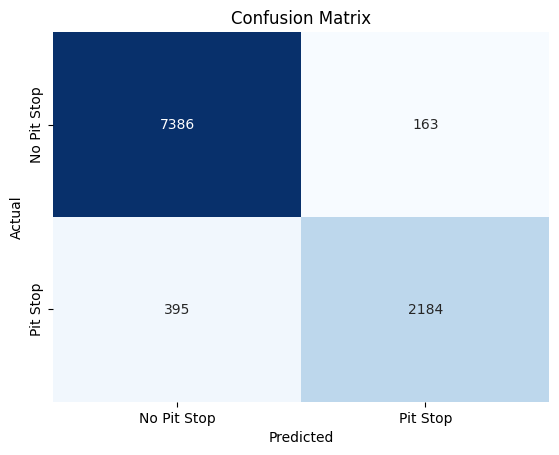

In [20]:
sns.heatmap(
    cm, annot=True, fmt='g',
    xticklabels=['No Pit Stop', 'Pit Stop'],
    yticklabels=['No Pit Stop', 'Pit Stop'],
    cmap='Blues',
    cbar=False
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusion_matrix.png")
plt.show()

## Interpretation of the Above Metrics

The Random Forest classifier model demonstrates strong predictive capability for pit stop events in Formula 1 race data, achieving a precision score of 0.931 and an F1-score of 0.887.

**Precision (0.931)**

A precision of 0.931 means that 93.1% of predicted pit stops are actual pit stops.
From a racing strategy perspective, this is particularly important. A high precision implies that the model is very reliable when it signals a pit stop, meaning race engineers or decision systems would rarely be misled into considering unnecessary pit actions. In practical terms, when the model says “pit now is likely”, it is usually correct.

This reduces wasted strategic attention and avoids unnecessary disruption to race rhythm caused by false alarms.

**Recall (0.847)**

A recall of 0.847 indicates that the model correctly identifies 84.7% of all true pit stops, while missing around 15.3% of them.

This introduces an important limitation: the model does not capture every pit event, particularly those that are less predictable or driven by sudden race dynamics such as reactive strategy changes, unexpected tyre degradation, or external race conditions.

In real racing terms, this means the model may occasionally fail to anticipate strategic or opportunistic pit stops, especially those that deviate from standard tyre wear patterns.

**F1 Score (0.887)**

An f1 score of 0.887 indicates that the model maintains a strong overall equilibrium between being correct and being complete in its predictions.

It confirms that the model is not biased toward only one behavior (e.g., over-predicting pits or ignoring them), but instead maintains a relatively stable predictive performance across both error types.

**Confusion Matrix Interpretation**

The confusion matrix further supports this behavior:

- True Negatives (7,386):
The model correctly identifies the majority of laps where no pit stop occurs, showing strong ability to recognize standard race conditions.

- True Positives (2,184):
These are correctly predicted pit stops, representing the core predictive strength of the model.

- False Positives (163):
These are rare incorrect pit predictions. The low number indicates the model is not overly aggressive in predicting pit stops, reinforcing its high precision.

- False Negatives (395):
These represent missed pit stops. These cases likely correspond to non-standard or reactive race strategies, where pit decisions are influenced by sudden race events not strongly reflected in historical lap patterns.

Overall, this produces a slightly conservative model behavior: it tends to only recommend pit stops when it is highly confident, rather than attempting to capture every possible pit event.

This makes it more suitable for decision-support scenarios where false alarms are more costly than missed opportunities, but less suitable for systems where full coverage of all pit events is critical.

# Feature Importances

In this section I talk about the effect each predictor variable has on the target.

One drawback of the Random Forest Model is it's limited interpretability. While one will be able to see how each predictor affects the target, one cannot see if such relationship is positive or negative.

In [21]:
feature_names = forest.named_steps['col_transform'].get_feature_names_out()

importances = forest.named_steps['forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

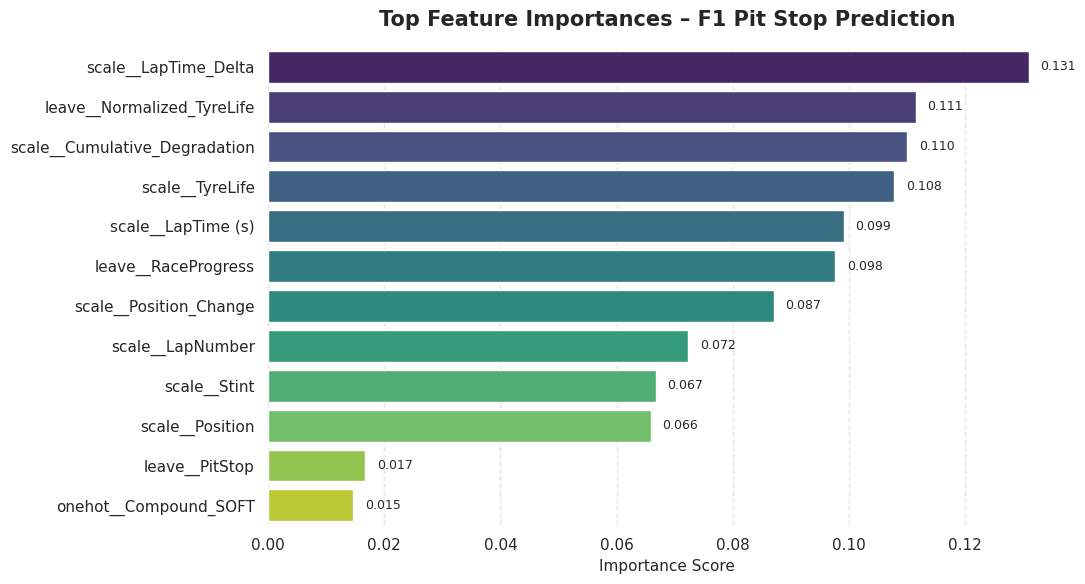

In [22]:
top_n = 12
top_features = feature_importance_df.head(top_n)

colors = sns.color_palette("viridis", n_colors=top_n)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette=colors,
    legend=False,
    hue='Feature'
)

plt.title('Top Feature Importances – F1 Pit Stop Prediction',
          fontsize=15, weight='bold', pad=15)

plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('')

for i, v in enumerate(top_features['Importance']):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)

ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

**Feature Importance Analysis**

The feature importance results reveal how the model prioritizes different types of information when predicting pit stop events in Formula 1 race data. Rather than relying on a single dominant variable, the model learns a combination of performance degradation, stint evolution, and race context signals.

1. **Primary Driver: Performance Degradation Signals**

The most influential features are those related to lap time behavior and degradation patterns, particularly:
- Lap time delta
- Raw lap time
- Cumulative degradation

Together, these variables form the core performance signal of the model. They capture how the car’s pace evolves over time and, more importantly, how it deviates from expected performance. A rising lap time delta or increasing degradation indicates that the tyre is losing effectiveness, which is one of the strongest real-world triggers for pit stop decisions.

In essence, the model is highly sensitive to pace deterioration patterns, meaning it has learned to associate declining performance with imminent pit stops.

2. **Secondary Driver: Tyre Wear and Stint Evolution**

The next most important group consists of features that describe how long the car has been on track with a given tyre set, including:
- Tyre life
- Normalized tyre life
- Stint number

These features provide a structural understanding of race strategy progression. While they are not as immediately reactive as lap time signals, they provide crucial context about whether a tyre is entering the end of its usable window.

This indicates the model is not purely reactive to performance drops—it also understands stint lifecycle progression, which is central to race strategy planning.

3. **Contextual and Race-State Features**

Another important group includes:
- Race progress
- Lap number
- Position
- Position change

These features introduce global race context into the model. They help the model understand:
- when in the race a pit stop is likely (early vs mid vs late race)
- whether a driver is under pressure (position changes)
- whether strategic windows are opening or closing

While individually less powerful than degradation signals, together they provide a temporal and strategic frame of reference for decision-making.

4. **Lower-Impact Features: Compound Information**

Interestingly, tyre compound features (soft, medium, intermediate, wet) have relatively low importance compared to performance-based variables.

This is a key insight. Rather than relying on tyre labels directly, the model learns the effects of those tyres indirectly through performance metrics such as lap time and degradation.

This suggests that tyre compound is not predictive on its own, but becomes meaningful only through its impact on car performance.

This is a more generalized and robust learning pattern, as it avoids overfitting to categorical race setups.

5. **Minor Signal: Historical Pit Behavior**

Previous pit stop indicators contribute minimally, suggesting that:
- pit behavior is not strongly repetitive at the lap-to-lap level,
- the model relies more on current race conditions than past actions.

This is consistent with the dynamic nature of race strategy in Formula 1, where decisions are highly situational rather than strictly historical.

Overall, the model prioritizes real-time performance degradation over static race attributes.

In other terms, it predicts pit stops mainly by detecting when the car is slowing down in a meaningful way, rather than relying on predefined race settings like tyre type or stint labels.


#Final Summary & Conclusion

This project developed a machine learning model to predict next-lap pit stop probability in Formula 1 race data using a Random Forest classifier.

The model demonstrated strong predictive performance, achieving high precision and a balanced F1-score, indicating reliable identification of pit stop events with relatively low misclassification. While recall was slightly lower, the model showed a deliberate tendency toward conservative predictions—favoring correctness over completeness.

Feature importance analysis revealed that pit stop decisions are primarily driven by performance degradation signals, particularly lap time changes and tyre wear progression. Contextual variables such as race progress, stint number, and position provided additional strategic structure, while categorical tyre compounds played a secondary role.

Overall, the model successfully captures the underlying logic of race strategy, where pit stops are largely triggered by measurable performance decline rather than static race conditions. This makes the model suitable for decision-support scenarios where prediction reliability is more important than exhaustive detection.